k-NN Accuracy: 1.00


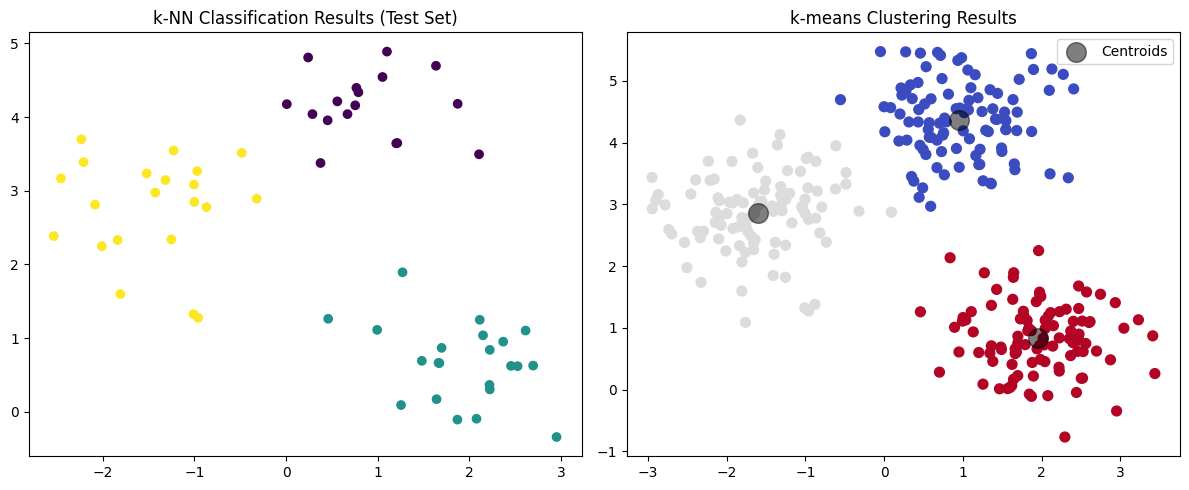

In [2]:
#bai 4
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

# 1. Tạo dữ liệu giả lập
X, y = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=0)

# Chia dữ liệu cho k-NN
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Demo 1: k-Nearest Neighbors (Phân loại) ---
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print(f"k-NN Accuracy: {accuracy_score(y_test, y_pred):.2f}")

# --- Demo 2: k-means (Phân cụm) ---
kmeans = KMeans(n_clusters=3, n_init='auto', random_state=42)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

# --- Trực quan hóa kết quả ---
plt.figure(figsize=(12, 5))

# Vẽ k-NN
plt.subplot(1, 2, 1)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='viridis', marker='o')
plt.title("k-NN Classification Results (Test Set)")

# Vẽ k-means
plt.subplot(1, 2, 2)
# Đã sửa lỗi: Thay 'vlag' bằng 'coolwarm' vì 'vlag' không phải colormap mặc định của Matplotlib
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='coolwarm')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5, label='Centroids')
plt.title("k-means Clustering Results")
plt.legend()

plt.tight_layout()
plt.show()